# <span style="color:blue"> GALAXY MODEL  gruppo G<span>

## Imports and setup

In [32]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import emcee
import corner
from time import time

%matplotlib widget
plt.close("all")

## Data loading, filtering and unit conversion

In [2]:
# load the data and filter it by only picking stars near the equatorial plane (|b| < 5 deg)
gaia = Table.read("d3.gz")
mask = abs(gaia['b']) < 5
gaia_filtered = gaia[mask]

# note: we should also filter by parallax error if we dind't do it in the query!!!!

# extract the relevant columns
l = gaia_filtered["l"]
b = gaia_filtered["b"]
parallax = gaia_filtered["parallax"]
parallax_error = gaia_filtered["parallax_error"]
radial_velocity = gaia_filtered["radial_velocity"]
radial_velocity_error = gaia_filtered["radial_velocity_error"]

# print table info
gaia.info

<Table length=349153>
         name          dtype    unit                  description                 n_bad
--------------------- ------- -------- ------------------------------------------ -----
                   ra float64      deg                            Right ascension     0
                  dec float64      deg                                Declination     0
             parallax float64      mas                                   Parallax     0
       parallax_error float64      mas                 Standard error of parallax     0
                 pmra float64 mas / yr Proper motion in right ascension direction     0
                pmdec float64 mas / yr     Proper motion in declination direction     0
      phot_g_mean_mag float32      mag                      G-band mean magnitude     0
     phot_bp_mean_mag float32      mag               Integrated BP mean magnitude   422
     phot_rp_mean_mag float32      mag               Integrated RP mean magnitude   426
      radi

In [3]:
# unit conversion:
#   [velocity] = km/s
#   [distance] = kpc
#   [longitude/latitude] = radians

d_from_sun = 1 / parallax # distance from sun in kpc
l_rad = np.radians(l) # longitude in radians
b_rad = np.radians(b) # latitude in radians

print(f"Number of stars: {len(d_from_sun)}")

Number of stars: 75659


## Model definition and naive comparison

In [4]:
def distance_from_gc(l_rad, d_from_sun, R0):
    """Calculate the distance of a star from the galactic center given its longitude, distance from the sun, and the sun's distance from the galactic center.

        Parameters:
        l_rad: longitude in radians
        d_from_sun: distance from the sun in kpc
        R0: distance of the sun from the galactic center in kpc

        Returns:
        distance from the galactic center in kpc
    """
    return np.sqrt(R0**2 + d_from_sun**2 - 2.0*R0*d_from_sun*np.cos(l_rad))

def velocity_model(l_rad, d_from_sun, R0, V_rot, U0, V0):
    """Calculate the expected radial velocity of a star given its longitude, distance from the sun, and the model parameters.

        Parameters:
        l_rad: longitude in radians
        d_from_sun: distance from the sun in kpc
        R0: distance of the sun from the galactic center in kpc
        V_rot: rotation velocity of the galaxy in km/s
        U0: solar motion in the radial direction in km/s
        V0: solar motion in the tangential direction in km/s

        Returns:
        expected radial velocity in km/s

    """

    R = distance_from_gc(l_rad, d_from_sun, R0)
    
    V_lsr_term = (U0 / np.cos(l_rad)) + (V0 / np.sin(l_rad))
    V_rot_term = V_rot*((1.0 / R) - (1.0 / R0))*R0*np.sin(l_rad)

    return V_rot_term + V_lsr_term

R0 = 8.0 # kpc

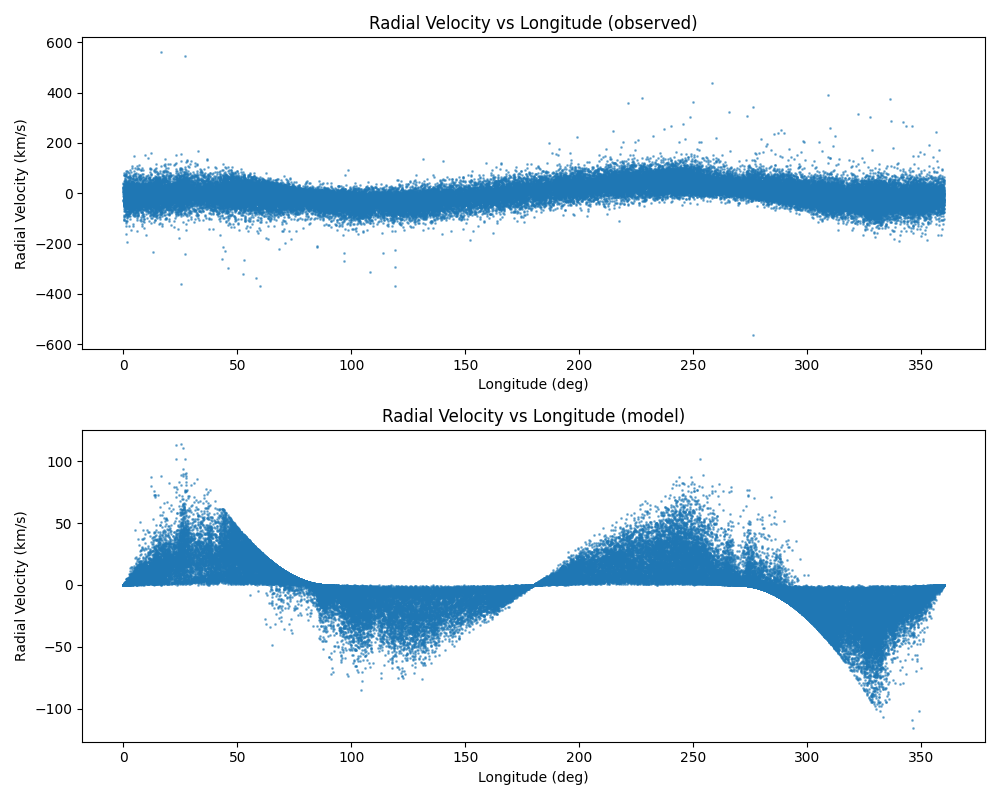

In [5]:
# plot the actual vs expected radial velocities for some initial guess of the parameters
# the lsr term for now is 0

V_rot = 200.0 # km/s
U0 = 0.0 # km/s
V0 = 0.0 # km/s

V_rad_exp = velocity_model(l_rad, d_from_sun, R0, V_rot, U0, V0)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.scatter(l, radial_velocity, s=1, label="Observed", alpha=0.5)
plt.xlabel("Longitude (deg)")
plt.ylabel("Radial Velocity (km/s)")
plt.title("Radial Velocity vs Longitude (observed)")

plt.subplot(2, 1, 2)
plt.scatter(l, V_rad_exp, s=1, label="Expected", alpha=0.5)
plt.xlabel("Longitude (deg)")
plt.ylabel("Radial Velocity (km/s)")
plt.title("Radial Velocity vs Longitude (model)")

plt.tight_layout()

plt.show()

## Statistical analysis

### Probability

In [6]:
def log_likelihood(theta, V_rad, l, d, error):
    V_rot, log_sigma_rot = theta
    
    R = distance_from_gc(l, d, R0)

    # V_rad as function of V_rot (and l)
    model =  velocity_model(l, d, R0, V_rot, 0.0, 0.0)

    sigma2 = error**2 + np.exp(log_sigma_rot)**2

    return -np.sum(np.log(np.sqrt(2.0*np.pi*sigma2)) + (0.5*(V_rad - model)**2)/sigma2)

def log_prior(theta):
    V_rot,  log_sigma_rot = theta

    # set the prior to be uniform, but set some bounds on the parameters
    if V_rot < 0.0 or V_rot > 400.0:
        if log_sigma_rot < 0.0 or log_sigma_rot > 5.0:
            return -np.inf

    return 0.0

def log_probability(theta, V_rad, l, d, error ):
    return log_likelihood(theta, V_rad, l, d, error) + log_prior(theta)

### Max likelyhood

In [7]:
# initial guess for the parameters
# we set some reasonable start values (well inside the prior bounds), then add some random noise to create the initial positions of the walkers
p0 = [100.0, np.log(20.0)] # initial guess for the parameters
pos = p0 + np.array([10.0, 0.5]) * np.random.randn(20, 2)   # 20 walkers, 2 parameters (V_rot, log_sigma_rot)

# number of walkers and dimensions can be inferred from the shape of the pos array
nwal, dim = pos.shape
num_iters = 5000

sampler = emcee.EnsembleSampler(nwal, dim, log_probability, args=(radial_velocity, l_rad, d_from_sun, radial_velocity_error))
sampler.run_mcmc(pos, num_iters, progress=True)

  0%|          | 3/5000 [00:00<10:29,  7.94it/s]

100%|██████████| 5000/5000 [10:22<00:00,  8.03it/s]


State([[189.23011986   3.56274966]
 [189.24279165   3.56227444]
 [188.97136178   3.5694304 ]
 [187.87030139   3.56359216]
 [189.17786375   3.5653025 ]
 [188.54346491   3.5686982 ]
 [186.06673504   3.56781548]
 [190.91460748   3.56557991]
 [188.11410908   3.56880931]
 [190.13037926   3.56543637]
 [188.21344464   3.5656257 ]
 [189.17566985   3.5641064 ]
 [187.5448121    3.56636083]
 [190.80353573   3.56341263]
 [190.35892312   3.56641854]
 [187.10332871   3.56672898]
 [189.51757078   3.56624686]
 [187.6621428    3.56335416]
 [187.77599052   3.56312469]
 [188.89805693   3.56230337]], log_prob=[-377234.31115213 -377234.55675934 -377234.46724308 -377234.20311156
 -377233.58272093 -377234.13034558 -377236.34179612 -377235.04082742
 -377234.3167716  -377234.12684995 -377233.6336043  -377233.79405255
 -377234.06817044 -377235.34239005 -377234.35788204 -377234.55038276
 -377233.69417297 -377234.43805671 -377234.44486162 -377234.47773581], blobs=None, random_state=('MT19937', array([1313387309, 

## Post processing

### Burn in

In [8]:
tau = sampler.get_autocorr_time()
burn_in = int(2 * np.max(tau))
thin = int(0.5 * np.min(tau))

samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)

In [9]:
# dump the samples to a file for later use
np.save(f"gaia_mcmc_samples_{time()}.npy", samples)

In [22]:
V_rot_mcmc, log_sigma_rot_mcmc = np.percentile(samples, [16, 50, 84], axis=0).T

# extract the best-fit parameters (the median of the posterior distribution) as medians
V_rot_best = V_rot_mcmc[1]
sigma_rot_best = np.exp(log_sigma_rot_mcmc[1])

# extract the uncertainties as the 16th and 84th percentiles (2/3s confidence interval)
V_rot_uncertainty = V_rot_mcmc[0] - V_rot_mcmc[2]
sigma_rot_uncertainty = np.exp(log_sigma_rot_mcmc[0]) - np.exp(log_sigma_rot_mcmc[2])

# print the best values
print(f"Best-fit V_rot: {V_rot_best:.2f} km/s ± {V_rot_uncertainty:.2f} km/s")
print(f"Best-fit sigma_rot: {sigma_rot_best:.2f} km/s ± {sigma_rot_uncertainty:.2f} km/s")

Best-fit V_rot: 188.76 km/s ± -2.42 km/s
Best-fit sigma_rot: 35.37 km/s ± -0.18 km/s


### Corner plot

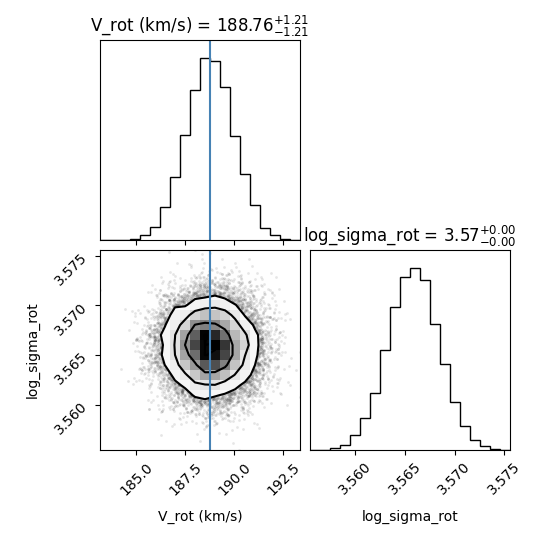

In [11]:
fig = corner.corner(
    samples, 
    labels=["V_rot (km/s)", "log_sigma_rot"], 
    truths=[V_rot_best, sigma_rot_best], 
    show_titles=True
)

### Trace plot

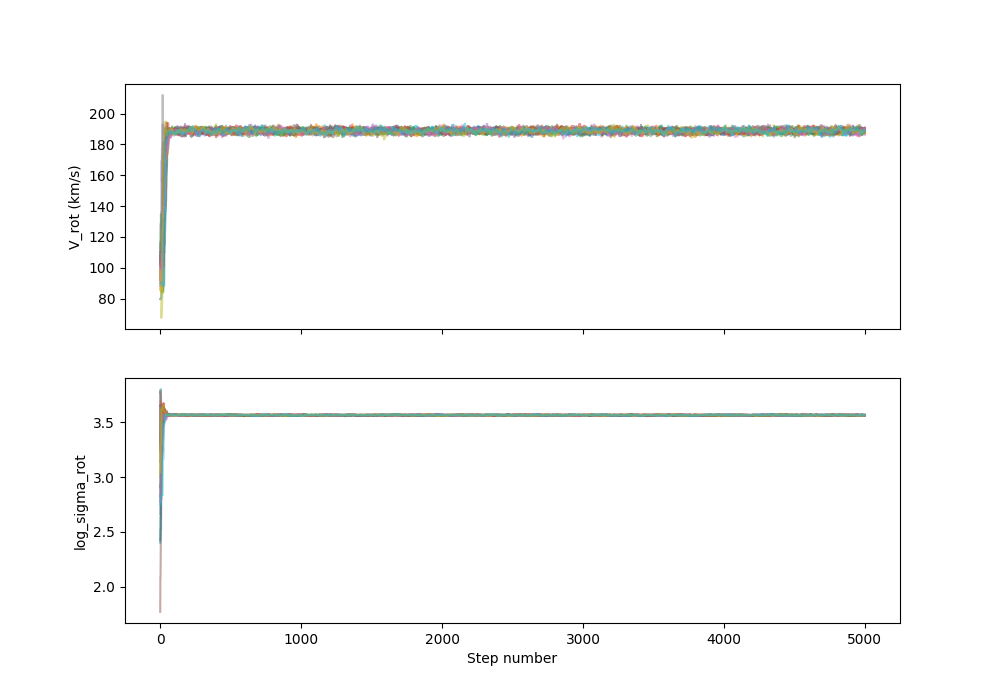

In [21]:
# trace plot to check for convergence for both parameters
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples_chain = sampler.get_chain()

parameter_labels = ["V_rot (km/s)", "log_sigma_rot"]

for i in range(dim):
    ax = axes[i]
    for walker in range(nwal):
        ax.plot(samples_chain[:, walker, i], alpha=0.5)
    ax.set_ylabel(f"{parameter_labels[i]}")

axes[-1].set_xlabel("Step number")

plt.show()

### Comparison

/tmp/ipykernel_6149/1226985902.py:32: RuntimeWarning: invalid value encountered in divide
  V_lsr_term = (U0 / np.cos(l_rad)) + (V0 / np.sin(l_rad))


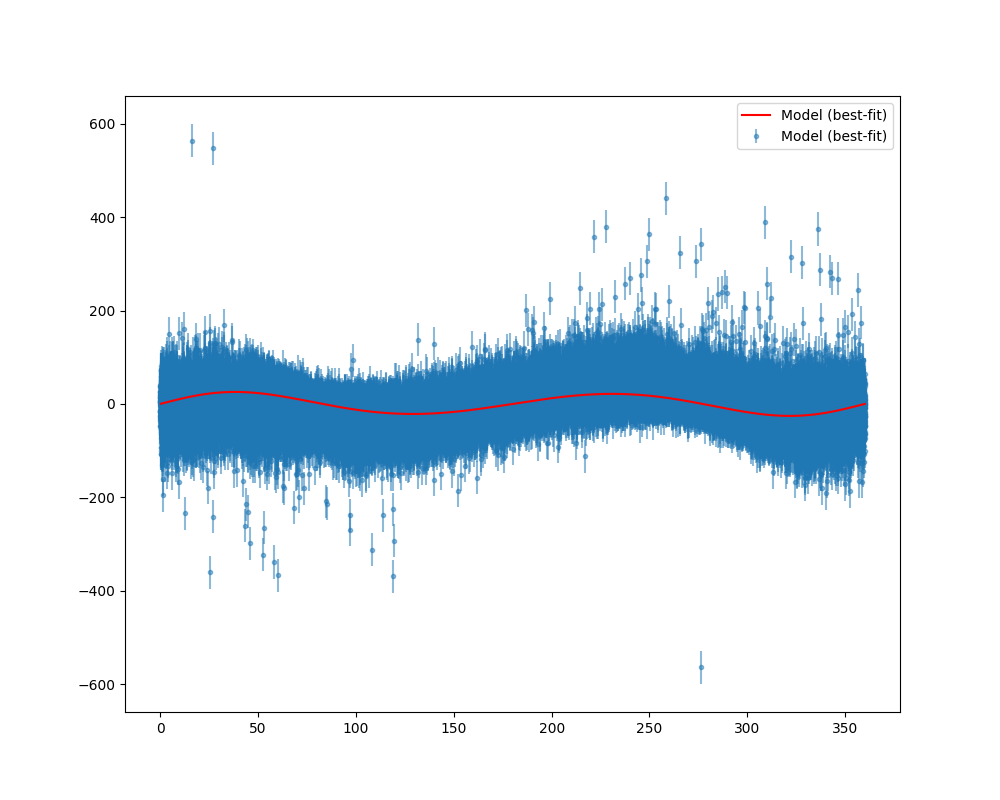

In [34]:
fig = plt.figure(figsize=(10, 8))

# plot the observed data
#plt.scatter(l, radial_velocity, s=1, label="Observed", alpha=0.5)
sigma = np.sqrt(sigma_rot_best**2 + radial_velocity_error**2)    # total uncertainty (model + measurement)
plt.errorbar(l, radial_velocity, yerr=sigma, fmt='.', label="Model (best-fit)", zorder=1, alpha=0.5)


# plot the model with the best-fit parameters

avg_dist_from_sun = np.mean(d_from_sun)

l_vals_vals = np.linspace(0, 2*np.pi, 1000)
l_vals_deg = np.degrees(l_vals_vals)
V_rad_vals = velocity_model(l_vals_vals, avg_dist_from_sun, R0, V_rot_best, 0.0, 0.0)
plt.plot(l_vals_deg, V_rad_vals, label="Model (best-fit)", color="red", zorder=2)

plt.legend()
plt.show()

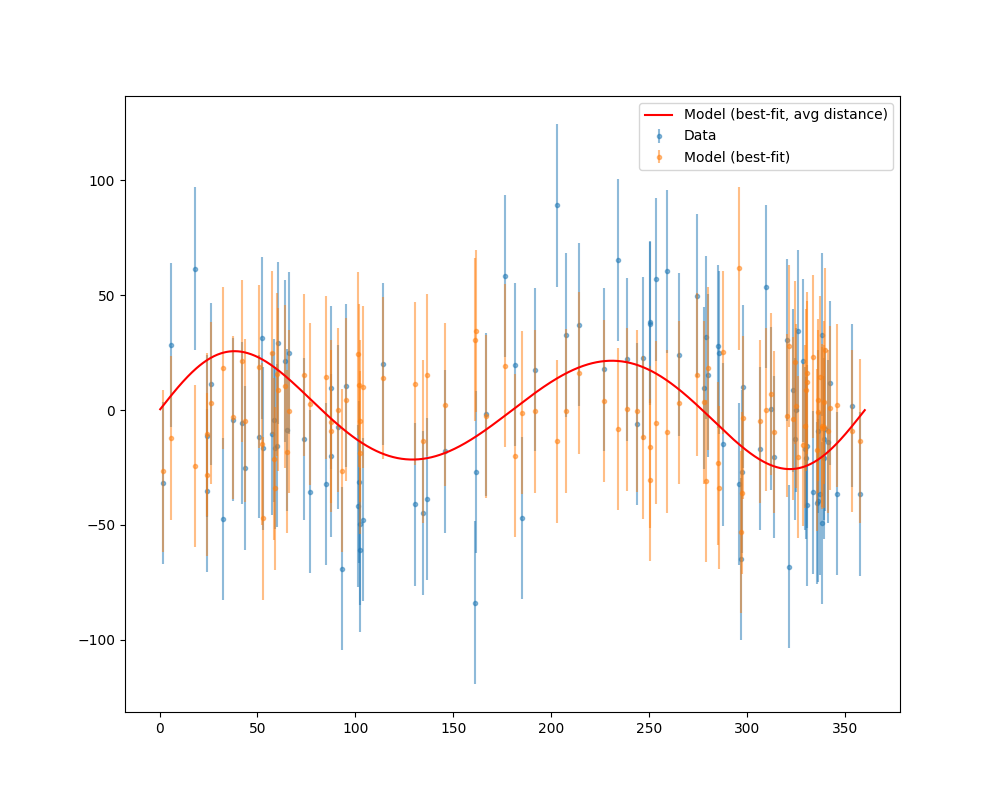

In [37]:
# extract a random subset of the data

n_samples = 100
indices = np.random.choice(len(d_from_sun), size=n_samples, replace=False)
l_subset = l[indices]
radial_velocity_subset = radial_velocity[indices]
radial_velocity_error_subset = radial_velocity_error[indices]
d_from_sun_subset = d_from_sun[indices]
sigma_subset = np.sqrt(sigma_rot_best**2 + radial_velocity_error_subset**2)    # total uncertainty (model + measurement)

plt.figure(figsize=(10, 8))
plt.errorbar(l_subset, radial_velocity_subset, yerr=sigma_subset, fmt='.', label="Data", zorder=1, alpha=0.5)
plt.errorbar(l_subset, velocity_model(l_subset, d_from_sun_subset, R0, V_rot_best, 0, 0), yerr=sigma_subset, fmt='.', label="Model (best-fit)", zorder=2, alpha=0.5)
plt.plot(l_vals_deg, V_rad_vals, label="Model (best-fit, avg distance)", color="red", zorder=3)
plt.legend()
plt.show()